<a href="https://colab.research.google.com/github/froz-zi/ML/blob/main/Clustering_Kmean/01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv('K Means Data.csv')

print("=== 5 Baris Pertama ===")
print(df.head())

print("\n=== Info Kolom & Tipe Data ===")
print(df.info())

print("\n=== Statistik Deskriptif ===")
print(df.describe())

print("\n=== Cek Missing Values ===")
print(df.isnull().sum())

print("\n=== Jumlah Baris & Kolom ===")
print(f"Shape: {df.shape}")

=== 5 Baris Pertama ===
         CSBLLM       CSBLL3M       CSBLL6M         BALLM        BALEOM
0  1.364000e+07  1.287011e+07  6.740054e+06  1.364000e+07  1.361000e+07
1  1.727548e+06  1.645849e+06  1.662925e+06  1.727548e+06  1.824000e+06
2  6.140795e+08  7.721898e+08  7.420138e+08  6.140795e+08  2.611729e+08
3  2.229861e+07  1.689339e+07  2.481476e+07  2.229861e+07  6.301518e+06
4  3.552897e+05  2.547015e+06  1.485497e+06  3.552897e+05  3.456123e+05

=== Info Kolom & Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205324 entries, 0 to 205323
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   CSBLLM   205324 non-null  float64
 1   CSBLL3M  205324 non-null  float64
 2   CSBLL6M  205324 non-null  float64
 3   BALLM    205324 non-null  float64
 4   BALEOM   205324 non-null  float64
dtypes: float64(5)
memory usage: 7.8 MB
None

=== Statistik Deskriptif ===
             CSBLLM       CSBLL3M       CSBLL6M       

In [20]:
# 2. AMBIL FITUR NUMERIK
# K-Means hanya bisa pakai angka
# ----------------------------------------------------------
X = df.select_dtypes(include=[np.number]).dropna()
print(f"\nFitur yang dipakai: {list(X.columns)}")


Fitur yang dipakai: ['CSBLLM', 'CSBLL3M', 'CSBLL6M', 'BALLM', 'BALEOM']


In [21]:
# 3. FEATURE SCALING
# Wajib! K-Means berbasis jarak Euclidean —
# kalau skalanya beda jauh, fitur besar akan mendominasi
# ----------------------------------------------------------
sc = StandardScaler()
X_scaled = sc.fit_transform(X)


In [22]:
# 4. ELBOW METHOD
# Hitung inertia untuk K = 1 sampai 10
# Inertia = total jarak kuadrat tiap titik ke centroidnya
# Makin banyak cluster → inertia makin kecil
# Tapi ada titik "siku" di mana tambahan cluster
# sudah tidak terlalu membantu — itulah K optimal
# ----------------------------------------------------------
inertias = []
K_range = range(1, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

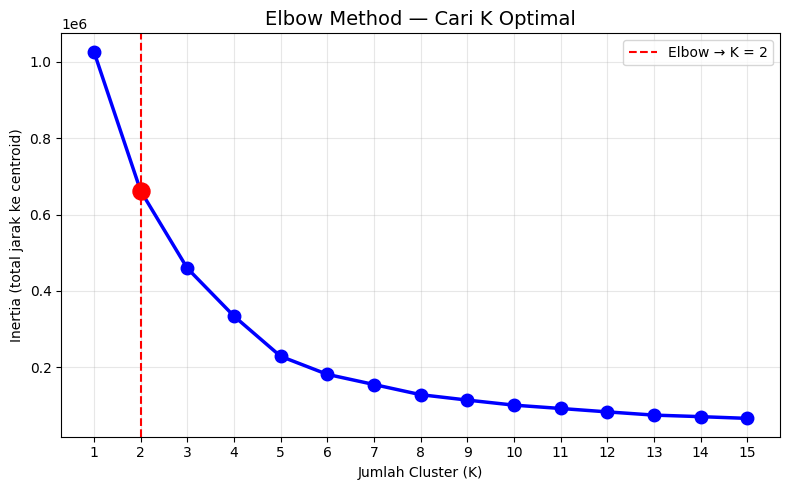

Titik Elbow terdeteksi: K = 2


In [23]:
# 5. PLOT ELBOW
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', markersize=9, linewidth=2.5)

# Tandai titik siku otomatis (metode sederhana)
# Cari K di mana penurunan inertia paling tajam berhenti
deltas = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
delta2 = [deltas[i] - deltas[i+1] for i in range(len(deltas)-1)]
elbow_k = int(np.argmax(delta2)) + 2   # +2 karena index mulai dari K=1

plt.axvline(x=elbow_k, color='red', linestyle='--', linewidth=1.5,
            label=f'Elbow → K = {elbow_k}')
plt.scatter([elbow_k], [inertias[elbow_k-1]],
            color='red', s=150, zorder=5)

plt.title('Elbow Method — Cari K Optimal', fontsize=14)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (total jarak ke centroid)')
plt.xticks(list(K_range))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Titik Elbow terdeteksi: K = {elbow_k}")

In [24]:
# 6. LATIH MODEL FINAL dengan K dari elbow
# Boleh ganti manual: best_k = 4  ← kalau dari grafik
# kamu lihat siku-nya di angka lain
# ----------------------------------------------------------
best_k = elbow_k   # ganti manual kalau perlu

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_

print(f"\nModel selesai dilatih dengan K = {best_k}")
print(f"\nJumlah anggota per cluster:")
print(df['Cluster'].value_counts().sort_index())


Model selesai dilatih dengan K = 2

Jumlah anggota per cluster:
Cluster
0    205293
1        31
Name: count, dtype: int64



PCA: 2 komponen = 96.8% informasi data


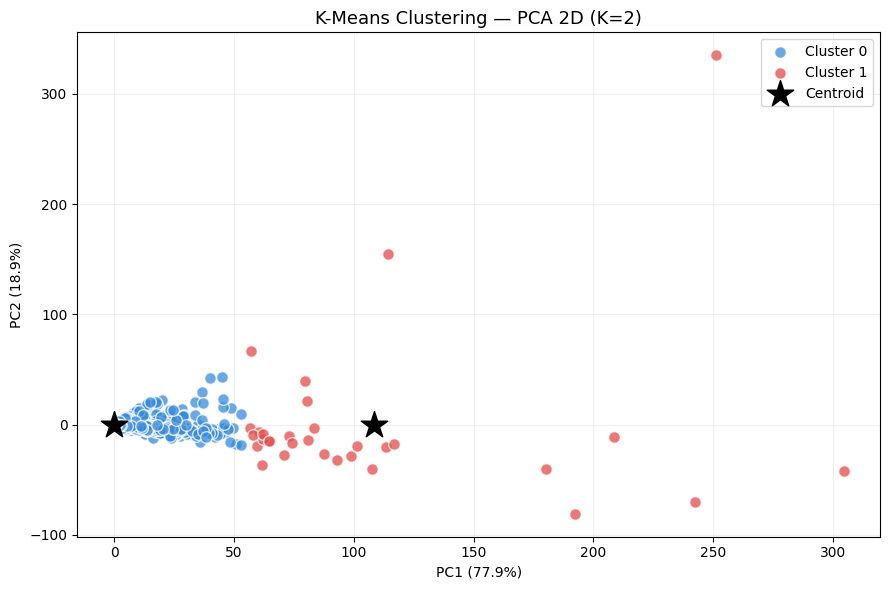

In [25]:
# 7. VISUALISASI CLUSTER
# Otomatis: 2 kolom → scatter langsung
#           > 2 kolom → pakai PCA dulu (ringkas ke 2D)
# ----------------------------------------------------------
colors = ['#378ADD','#E24B4A','#1D9E75','#BA7517','#7F77DD','#D85A30']

if X.shape[1] == 2:
    col1, col2 = X.columns[0], X.columns[1]
    centroids_orig = sc.inverse_transform(kmeans.cluster_centers_)

    plt.figure(figsize=(9, 6))
    for i in range(best_k):
        mask = df['Cluster'] == i
        plt.scatter(df.loc[mask, col1], df.loc[mask, col2],
                    c=colors[i % len(colors)],
                    label=f'Cluster {i}', alpha=0.75, s=70, edgecolors='w')

    plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
                marker='*', s=400, c='black', label='Centroid', zorder=5)

    plt.title(f'K-Means Clustering (K={best_k})', fontsize=13)
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

else:
    from sklearn.decomposition import PCA

    # PCA meringkas semua fitur ke 2 dimensi agar bisa diplot
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    var = pca.explained_variance_ratio_
    centroids_pca = pca.transform(kmeans.cluster_centers_)

    print(f"\nPCA: 2 komponen = {sum(var)*100:.1f}% informasi data")

    plt.figure(figsize=(9, 6))
    for i in range(best_k):
        mask = df['Cluster'] == i
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i % len(colors)],
                    label=f'Cluster {i}', alpha=0.75, s=70, edgecolors='w')

    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='*', s=400, c='black', label='Centroid', zorder=5)

    plt.title(f'K-Means Clustering — PCA 2D (K={best_k})', fontsize=13)
    plt.xlabel(f'PC1 ({var[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({var[1]*100:.1f}%)')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [26]:
# 8. PROFIL TIAP CLUSTER
# Rata-rata nilai tiap fitur per cluster
# Dari sini kita bisa beri "nama" ke tiap cluster
# Contoh: Cluster 0 = "Muda, gaji rendah"
#         Cluster 1 = "Tua, gaji tinggi"
# ----------------------------------------------------------
print("\n=== Profil Rata-rata Tiap Cluster ===")
print(df.groupby('Cluster')[list(X.columns)].mean().round(2))


=== Profil Rata-rata Tiap Cluster ===
               CSBLLM       CSBLL3M       CSBLL6M         BALLM        BALEOM
Cluster                                                                      
0        5.983053e+08  5.824309e+08  5.682226e+08  6.820911e+08  6.762099e+08
1        2.369369e+11  2.267702e+11  2.209014e+11  3.763875e+11  3.227305e+11
